# 06 — Physical resources, crossover analysis, FeMoCo benchmark

Surface-code physical qubit overhead, wall-clock time at three physical error
rates, scaling exponent fits, and the classical–quantum crossover for all three
encodings (PauliLCU, DF, THC). Closes with a FeMoCo benchmark comparison and
extrapolation to chemically meaningful active-space sizes.

In [9]:
import json
import math
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from math import comb

sys.path.insert(0, ".")
from config import load_config, ensure_dirs
cfg = load_config()
ensure_dirs(cfg)
data_dir = cfg["paths"]["data_dir"]
fig_dir = cfg["paths"]["figures_dir"]

## Load all results

In [10]:
with open(os.path.join(data_dir, "pauli_lcu_results.json")) as f:
    lcu = json.load(f)
with open(os.path.join(data_dir, "df_results.json")) as f:
    df_all = json.load(f)
df = df_all["analytical"]
with open(os.path.join(data_dir, "thc_results.json")) as f:
    thc = json.load(f)

labels = [a["label"] for a in cfg["active_spaces"]]
norbs = np.array([a["norb"] for a in cfg["active_spaces"]])
epsilon = cfg["qpe"]["epsilon_ha"]

## Surface-code overhead

Rotated surface code: each logical qubit needs $2d^2$ physical qubits with
distance $d$ chosen so the per-cycle logical error rate stays under the budget
implied by the total operation count. A small magic-state factory footprint is
added on top.

$$N_{\text{phys}} = N_{\text{logical}} \cdot 2d^2 + N_{\text{factories}} \cdot 15 d^2$$

Cycle time is $1\,\mu s$, with $d$ surface-code cycles per T-gate.

In [11]:
def surface_code(t_count, n_logical, p_phys,
                 p_threshold=None, p_target_per_gate=None):
    if p_threshold is None:
        p_threshold = cfg["surface_code"]["threshold"]
    if p_target_per_gate is None:
        p_target_per_gate = cfg["surface_code"]["target_logical_error_per_gate"]
    p_logical_needed = p_target_per_gate / t_count if t_count > 0 else 1e-15
    d = 3
    while d < 201:
        p_logical = 0.1 * (p_phys / p_threshold) ** ((d + 1) / 2)
        if p_logical < p_logical_needed:
            break
        d += 2
    phys_per_logical = 2 * d ** 2
    data_phys = n_logical * phys_per_logical
    n_factories = max(1, min(n_logical, cfg["surface_code"]["max_factories"]))
    fac_q = cfg["surface_code"]["factory_qubits_per_factory_per_d2"]
    factory_phys = n_factories * fac_q * d ** 2
    total_phys = data_phys + factory_phys
    wall_us = t_count * d * cfg["surface_code"]["cycle_time_us"]
    wall_days = wall_us / (3.6e9 * 24)
    return {
        "code_distance": d,
        "data_physical": int(data_phys),
        "factory_physical": int(factory_phys),
        "total_physical": int(total_phys),
        "wall_clock_days": float(wall_days),
    }

In [12]:
error_rates = cfg["surface_code"]["physical_error_rates"]
physical = {"PauliLCU": {}, "DF": {}, "THC": {}}

for label in labels:
    for method, source in [("PauliLCU", lcu), ("DF", df), ("THC", thc)]:
        r = source[label]
        physical[method][label] = {}
        for p in error_rates:
            physical[method][label][f"p={p}"] = surface_code(
                r["t_total"], r["logical_qubits"], p
            )

# Print at p = 1e-3
print(f"{'Space':>10} {'Method':>10} {'d':>4} {'Phys':>10} {'Wall(d)':>10}")
for label in labels:
    for method in ["PauliLCU", "DF", "THC"]:
        sc = physical[method][label]["p=0.001"]
        space_str = lcu[label]["active_space"] if method == "PauliLCU" else ""
        print(f"{space_str:>10} {method:>10} {sc['code_distance']:>4} "
              f"{sc['total_physical']:>10,} {sc['wall_clock_days']:>10.2f}")
    print()

     Space     Method    d       Phys    Wall(d)
  (4e, 4o)   PauliLCU   17     30,056       0.01
                   DF   17     34,102       0.00
                  THC   17     36,992       0.00

  (8e, 8o)   PauliLCU   21     55,566       0.95
                   DF   19     51,984       0.10
                  THC   19     57,760       0.04

(12e, 12o)   PauliLCU   23     75,118      10.91
                   DF   21     74,088       0.73
                  THC   19     68,590       0.12

(16e, 16o)   PauliLCU   25     96,250      74.74
                   DF   23     98,394       3.43
                  THC   21     95,256       0.36

(20e, 20o)   PauliLCU   27    122,472     403.93
                   DF   23    110,032      12.95
                  THC   21    106,722       0.45

(24e, 24o)   PauliLCU   27    129,762     841.60
                   DF   23    119,554      21.87
                  THC   21    119,070       1.23



## Scaling exponents

In [13]:
t_lcu = np.array([lcu[l]["t_total"] for l in labels])
t_df = np.array([df[l]["t_total"] for l in labels])
t_thc = np.array([thc[l]["t_total"] for l in labels])

log_n = np.log(norbs)
b_lcu, log_a_lcu = np.polyfit(log_n, np.log(t_lcu), 1)
b_df, log_a_df = np.polyfit(log_n, np.log(t_df), 1)
b_thc, log_a_thc = np.polyfit(log_n, np.log(t_thc), 1)

print(f"PauliLCU: T ~ N^{b_lcu:.2f}")
print(f"DF:       T ~ N^{b_df:.2f}")
print(f"THC:      T ~ N^{b_thc:.2f}")

PauliLCU: T ~ N^6.32
DF:       T ~ N^4.81
THC:      T ~ N^3.07


## Classical vs quantum crossover

Classical FCI cost: dimension of the Hilbert space squared, where
$\dim = \binom{N}{N/2}^2$ for half-filling and Davidson scales as $\dim^2$.

In [14]:
crossover = {"PauliLCU": None, "DF": None, "THC": None}
fits = {
    "PauliLCU": (log_a_lcu, b_lcu),
    "DF": (log_a_df, b_df),
    "THC": (log_a_thc, b_thc),
}

print(f"{'N':>4} {'FCI ops':>14} {'PauliLCU':>16} {'DF':>16} {'THC':>16}")
for N in [4, 8, 12, 16, 20, 25, 30, 40, 50, 60, 80, 100]:
    n_alpha = N // 2
    dim = comb(N, n_alpha)
    fci_ops = dim ** 2
    fci_str = f"{fci_ops:.2e}" if fci_ops > 1e10 else f"{fci_ops:,}"
    row = f"{N:>4} {fci_str:>14}"
    for method, (la, b) in fits.items():
        cost = np.exp(la) * N ** b
        if crossover[method] is None and cost < fci_ops:
            crossover[method] = N
        row += f" {cost:>16,.0f}"
    print(row)

print()
for method in ["PauliLCU", "DF", "THC"]:
    print(f"Crossover ({method}): ~{crossover[method]} orbitals")

   N        FCI ops         PauliLCU               DF              THC
   4             36       40,615,776       16,727,370       18,369,615
   8          4,900    3,248,459,522      470,625,635      153,979,572
  12        853,776   42,155,183,214    3,314,601,068      534,067,147
  16    165,636,900  259,812,573,086   13,241,082,685    1,290,702,500
  20       3.41e+10 1,064,838,538,512   38,768,332,247    2,559,072,892
  25       2.70e+13 4,364,227,256,724  113,509,115,599    5,073,867,966
  30       2.41e+16 13,818,384,801,630  273,044,105,156    8,875,961,524
  40       1.90e+22 85,166,042,167,541 1,090,749,534,803   21,450,908,930
  50       1.60e+28 349,051,944,620,822 3,193,586,307,687   42,530,668,035
  60       1.40e+34 1,105,197,736,689,063 7,682,113,555,573   74,400,945,311
  80       1.16e+46 6,811,600,516,091,160 30,688,308,697,406  179,807,888,747
 100       1.02e+58 27,917,258,400,296,624 89,851,757,287,081  356,504,689,434

Crossover (PauliLCU): ~25 orbitals
Crossover

## FeMoCo benchmark

Lee et al. 2021 (PRX Quantum 2, 030305) report THC resources for the FeMoco
active space at (54e, 54o).

In [15]:
femoco = cfg["femoco_benchmark"]

print(f"{'Metric':<28} {'FeMoCo':>16} {'TiO2 (12,12)':>16} {'TiO2 (24,24)':>16}")

metrics = [
    ("Active space", femoco["active_space"],
     thc["target"]["active_space"], thc["xxlarge"]["active_space"]),

    ("Encoding", femoco["encoding"], "THC", "THC"),

    ("Lambda", f"{float(femoco['lambda']):.1f}",
     f"{float(thc['target']['lambda_total']):.1f}",
     f"{float(thc['xxlarge']['lambda_total']):.1f}"),

    ("T-gates", f"{float(femoco['t_gates']):.2e}",
     f"{float(thc['target']['t_total']):.2e}",
     f"{float(thc['xxlarge']['t_total']):.2e}"),

    ("Logical qubits", f"{int(femoco['logical_qubits']):,}",
     f"{int(thc['target']['logical_qubits']):,}",
     f"{int(thc['xxlarge']['logical_qubits']):,}"),

    ("Phys qubits (p=1e-3)",
     f"{int(physical['THC']['target']['p=0.001']['total_physical']):,}",
     f"{int(physical['THC']['target']['p=0.001']['total_physical']):,}",
     f"{int(physical['THC']['xxlarge']['p=0.001']['total_physical']):,}"),

    ("Wall (p=1e-3)", f"{float(femoco['wall_days']):.1f} d",
     f"{float(physical['THC']['target']['p=0.001']['wall_clock_days']):.2f} d",
     f"{float(physical['THC']['xxlarge']['p=0.001']['wall_clock_days']):.2f} d"),
]

for row in metrics:
    print(f"{row[0]:<28} {row[1]:>16} {row[2]:>16} {row[3]:>16}")

Metric                                 FeMoCo     TiO2 (12,12)     TiO2 (24,24)
Active space                       (54e, 54o)       (12e, 12o)       (24e, 24o)
Encoding                                  THC              THC              THC
Lambda                                  306.3             66.0            268.6
T-gates                              3.50e+10         5.61e+08         5.07e+09
Logical qubits                          2,196               65              105
Phys qubits (p=1e-3)                   68,590           68,590          119,070
Wall (p=1e-3)                           4.0 d           0.12 d           1.23 d


## Extrapolation to 50–100 orbitals (THC)

In [16]:
# Extrapolate logical-qubit count linearly with N
lq_thc = np.array([thc[l]["logical_qubits"] for l in labels])
lq_slope, lq_int = np.polyfit(norbs, lq_thc, 1)

print(f"{'N':>4} {'T-gates':>16} {'Q_L':>5} {'Phys(1e-3)':>14} "
      f"{'Wall(1e-3)':>12} {'Phys(1e-5)':>14} {'Wall(1e-5)':>12}")
for N in cfg["extrapolation"]["target_orbitals"]:
    t_extr = np.exp(log_a_thc) * N ** b_thc
    lq_extr = int(lq_slope * N + lq_int)
    sc3 = surface_code(t_extr, lq_extr, 1e-3)
    sc5 = surface_code(t_extr, lq_extr, 1e-5)
    print(f"{N:>4} {t_extr:>16,.0f} {lq_extr:>5} "
          f"{sc3['total_physical']:>14,} {sc3['wall_clock_days']:>10.2f} d "
          f"{sc5['total_physical']:>14,} {sc5['wall_clock_days']:>10.2f} d")

   N          T-gates   Q_L     Phys(1e-3)   Wall(1e-3)     Phys(1e-5)   Wall(1e-5)
  30    8,875,961,524   126        137,592       2.16 d         15,288       0.72 d
  40   21,450,908,930   161        202,078       5.71 d         18,718       1.74 d
  50   42,530,668,035   196        239,108      11.32 d         22,148       3.45 d
  60   74,400,945,311   231        276,138      19.81 d         25,578       6.03 d
  80  179,807,888,747   301        413,750      52.03 d         53,622      18.73 d
 100  356,504,689,434   372        502,500     103.16 d         65,124      37.14 d


## Plots

Muted, professional palette (no rainbow). Three panels: T-gate scaling,
classical–quantum crossover, and physical qubit overhead under three error
rates.

saved figures/scaling_summary.png


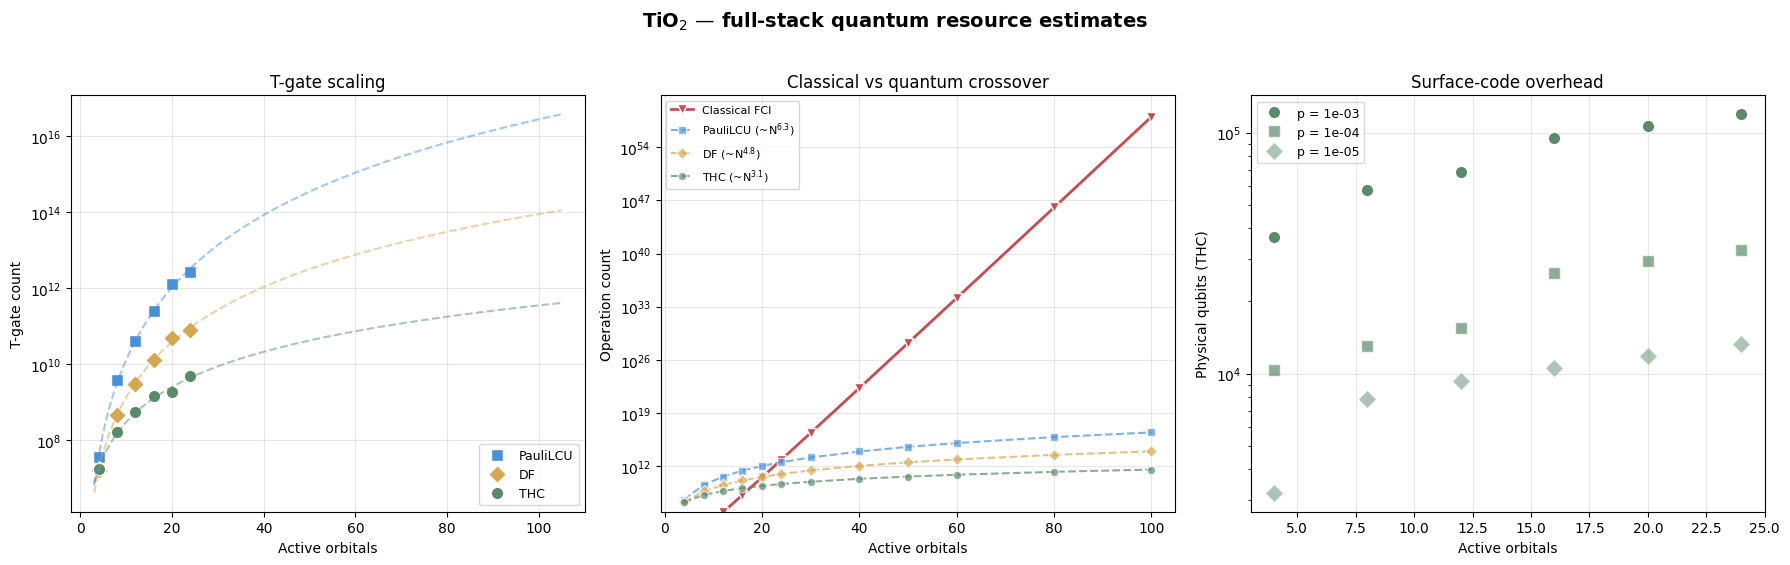

In [17]:
# Muted earth-tone palette
C_LCU = cfg["plot"]["color_pauli_lcu"]
C_DF = cfg["plot"]["color_df"]
C_THC = cfg["plot"]["color_thc"]
C_FCI = cfg["plot"]["color_fci"]

extrap_n = np.array(cfg["extrapolation"]["target_orbitals"])
n_fit = np.linspace(3, 105, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("TiO$_2$ — full-stack quantum resource estimates",
             fontsize=14, fontweight="bold", y=1.02)

# Panel 1: T-gate scaling
ax = axes[0]
ax.semilogy(norbs, t_lcu, "s", color=C_LCU, ms=9, mec="white", label="PauliLCU")
ax.semilogy(norbs, t_df, "D", color=C_DF, ms=9, mec="white", label="DF")
ax.semilogy(norbs, t_thc, "o", color=C_THC, ms=9, mec="white", label="THC")
ax.semilogy(n_fit, np.exp(log_a_lcu) * n_fit**b_lcu, "--", color=C_LCU, alpha=0.5)
ax.semilogy(n_fit, np.exp(log_a_df) * n_fit**b_df, "--", color=C_DF, alpha=0.5)
ax.semilogy(n_fit, np.exp(log_a_thc) * n_fit**b_thc, "--", color=C_THC, alpha=0.5)
ax.set(xlabel="Active orbitals", ylabel="T-gate count",
       title=f"T-gate scaling")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

# Panel 2: Classical-quantum crossover
ax = axes[1]
all_n = np.concatenate([norbs, extrap_n])
fci_cost = np.array([comb(N, N // 2) ** 2 for N in all_n], dtype=float)
ax.semilogy(all_n, fci_cost, "v-", color=C_FCI, ms=7, mec="white",
            label="Classical FCI", linewidth=2)
ax.semilogy(all_n, np.exp(log_a_lcu) * all_n**b_lcu, "s--",
            color=C_LCU, ms=6, mec="white", alpha=0.7,
            label=f"PauliLCU (~N$^{{{b_lcu:.1f}}}$)")
ax.semilogy(all_n, np.exp(log_a_df) * all_n**b_df, "D--",
            color=C_DF, ms=6, mec="white", alpha=0.7,
            label=f"DF (~N$^{{{b_df:.1f}}}$)")
ax.semilogy(all_n, np.exp(log_a_thc) * all_n**b_thc, "o--",
            color=C_THC, ms=6, mec="white", alpha=0.7,
            label=f"THC (~N$^{{{b_thc:.1f}}}$)")
ax.set(xlabel="Active orbitals", ylabel="Operation count",
       title="Classical vs quantum crossover")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=1e6)

# Panel 3: Physical qubit overhead at three error rates (THC)
ax = axes[2]
for p, marker, alpha in [(1e-3, "o", 1.0), (1e-4, "s", 0.7), (1e-5, "D", 0.5)]:
    phys = [physical["THC"][l][f"p={p}"]["total_physical"] for l in labels]
    ax.semilogy(norbs, phys, marker, color=C_THC, ms=9, mec="white",
                alpha=alpha, label=f"p = {p:.0e}")
ax.set(xlabel="Active orbitals", ylabel="Physical qubits (THC)",
       title="Surface-code overhead")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(fig_dir, "scaling_summary.png")
plt.savefig(fig_path, dpi=cfg["plot"]["dpi"], bbox_inches="tight")
print(f"saved {fig_path}")
plt.show()

## Save consolidated summary

In [18]:
summary = {
    "scaling_exponents": {
        "PauliLCU": float(b_lcu),
        "DF": float(b_df),
        "THC": float(b_thc),
    },
    "crossover_orbitals": crossover,
    "physical_resources": {
        method: {
            label: {
                str(p): physical[method][label][f"p={p}"] for p in error_rates
            } for label in labels
        } for method in ["PauliLCU", "DF", "THC"]
    },
    "femoco_benchmark": femoco,
}
summary_path = os.path.join(data_dir, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"saved {summary_path}")

saved data/summary.json
